# 15.836 genomas antiguos. 10.000 años de selección natural.

> **Paper:** Ancient DNA reveals pervasive directional selection across West Eurasia  
> **Journal:** Nature (2026)  
> **DOI:** [10.1038/s41586-026-10358-1](https://doi.org/10.1038/s41586-026-10358-1)  
> **Datos:** Supplementary Tables 1 y 5 (22.274 individuos + 696 tests poligénicos)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-16-adn-antiguo-seleccion-direccional-eurasia/notebook.ipynb)

[Pendiente]

## ¿Seguimos evolucionando?

El ADN antiguo cambió nuestra forma de entender las migraciones humanas. Pero revelar la **selección natural en acción** —distinguir qué alelos subieron de frecuencia porque daban ventaja, y no simplemente porque una migración los trajo— requería algo que hasta ahora no existía: una muestra enorme y un método estadístico capaz de separar ambas señales.

Un equipo liderado por David Reich reunió **15.836 genomas** de individuos de Eurasia occidental que vivieron en los últimos 10.000 años — 10.016 de ellos con datos nuevos. Desarrollaron un test que busca **tendencias consistentes** en el cambio de frecuencia alélica a lo largo del tiempo y lo aplicaron a **9,7 millones de variantes**.

El resultado: la selección natural no descansó. Cientos de alelos muestran señales claras de selección direccional. Y cuando los combinan en puntuaciones poligénicas — asociaciones genéticas que hoy predicen rasgos complejos — aparecen cambios de hasta una desviación estándar en combinaciones de alelos que hoy predicen rasgos complejos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_BONFERRONI = 7.18e-05   # 0.05 / 696 fenotipos
N_TOP = 20                      # Señales más fuertes a mostrar
FUENTE = 'Fuente: Reich et al. (2026), Nature | Datos: Supplementary Tables'

COLOR_DATOS = '#2563EB'         # Azul CaM
COLOR_ALERTA = '#DC2626'        # Rojo — señales decrecientes
COLOR_AUMENTO = '#059669'       # Emerald — señales crecientes
COLOR_REF = '#D97706'           # Amber — umbrales
COLOR_CONTEXTO = '#BBBBBB'      # Gris
COLOR_VIOLETA = '#7C3AED'       # Violeta — correlaciones

# ══════════════════════════════════════════════════════════════
import csv
import math
import os
import urllib.request
import statistics
from collections import Counter

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# ── Cargar datos ──
with open('datos/seleccion_poligeica.csv') as f:
    phenos = list(csv.DictReader(f))
with open('datos/individuos_antiguos.csv') as f:
    indivs = list(csv.DictReader(f))

# Parsear valores numéricos
for p in phenos:
    p['gamma'] = float(p['gamma']) if p['gamma'] else None
    p['gamma_p'] = float(p['gamma_p']) if p['gamma_p'] else None
    p['gamma_z'] = float(p['gamma_z']) if p['gamma_z'] else None

for ind in indivs:
    ind['date_bp'] = float(ind['date_bp']) if ind['date_bp'] else None
    ind['lat'] = float(ind['lat']) if ind['lat'] else None
    ind['lon'] = float(ind['lon']) if ind['lon'] else None
    ind['unrelated'] = ind['unrelated'] == '1'

unrel = [r for r in indivs if r['unrelated']]

print(f"Fenotipos cargados: {len(phenos)}")
print(f"Individuos cargados: {len(indivs)} ({len(unrel)} no emparentados)")
sig_bonf = [p for p in phenos if p['gamma_p'] and p['gamma_p'] < UMBRAL_BONFERRONI]
print(f"Señales Bonferroni-significativas: {len(sig_bonf)} de {len(phenos)}")
dates = [r['date_bp'] for r in unrel if r['date_bp'] is not None]
print(f"Rango temporal: {min(dates):.0f} – {max(dates):.0f} BP")

Fenotipos cargados: 696
Individuos cargados: 22274 (20374 no emparentados)
Señales Bonferroni-significativas: 77 de 696
Rango temporal: 0 – 18104 BP


## Las señales más fuertes

Aquí están.

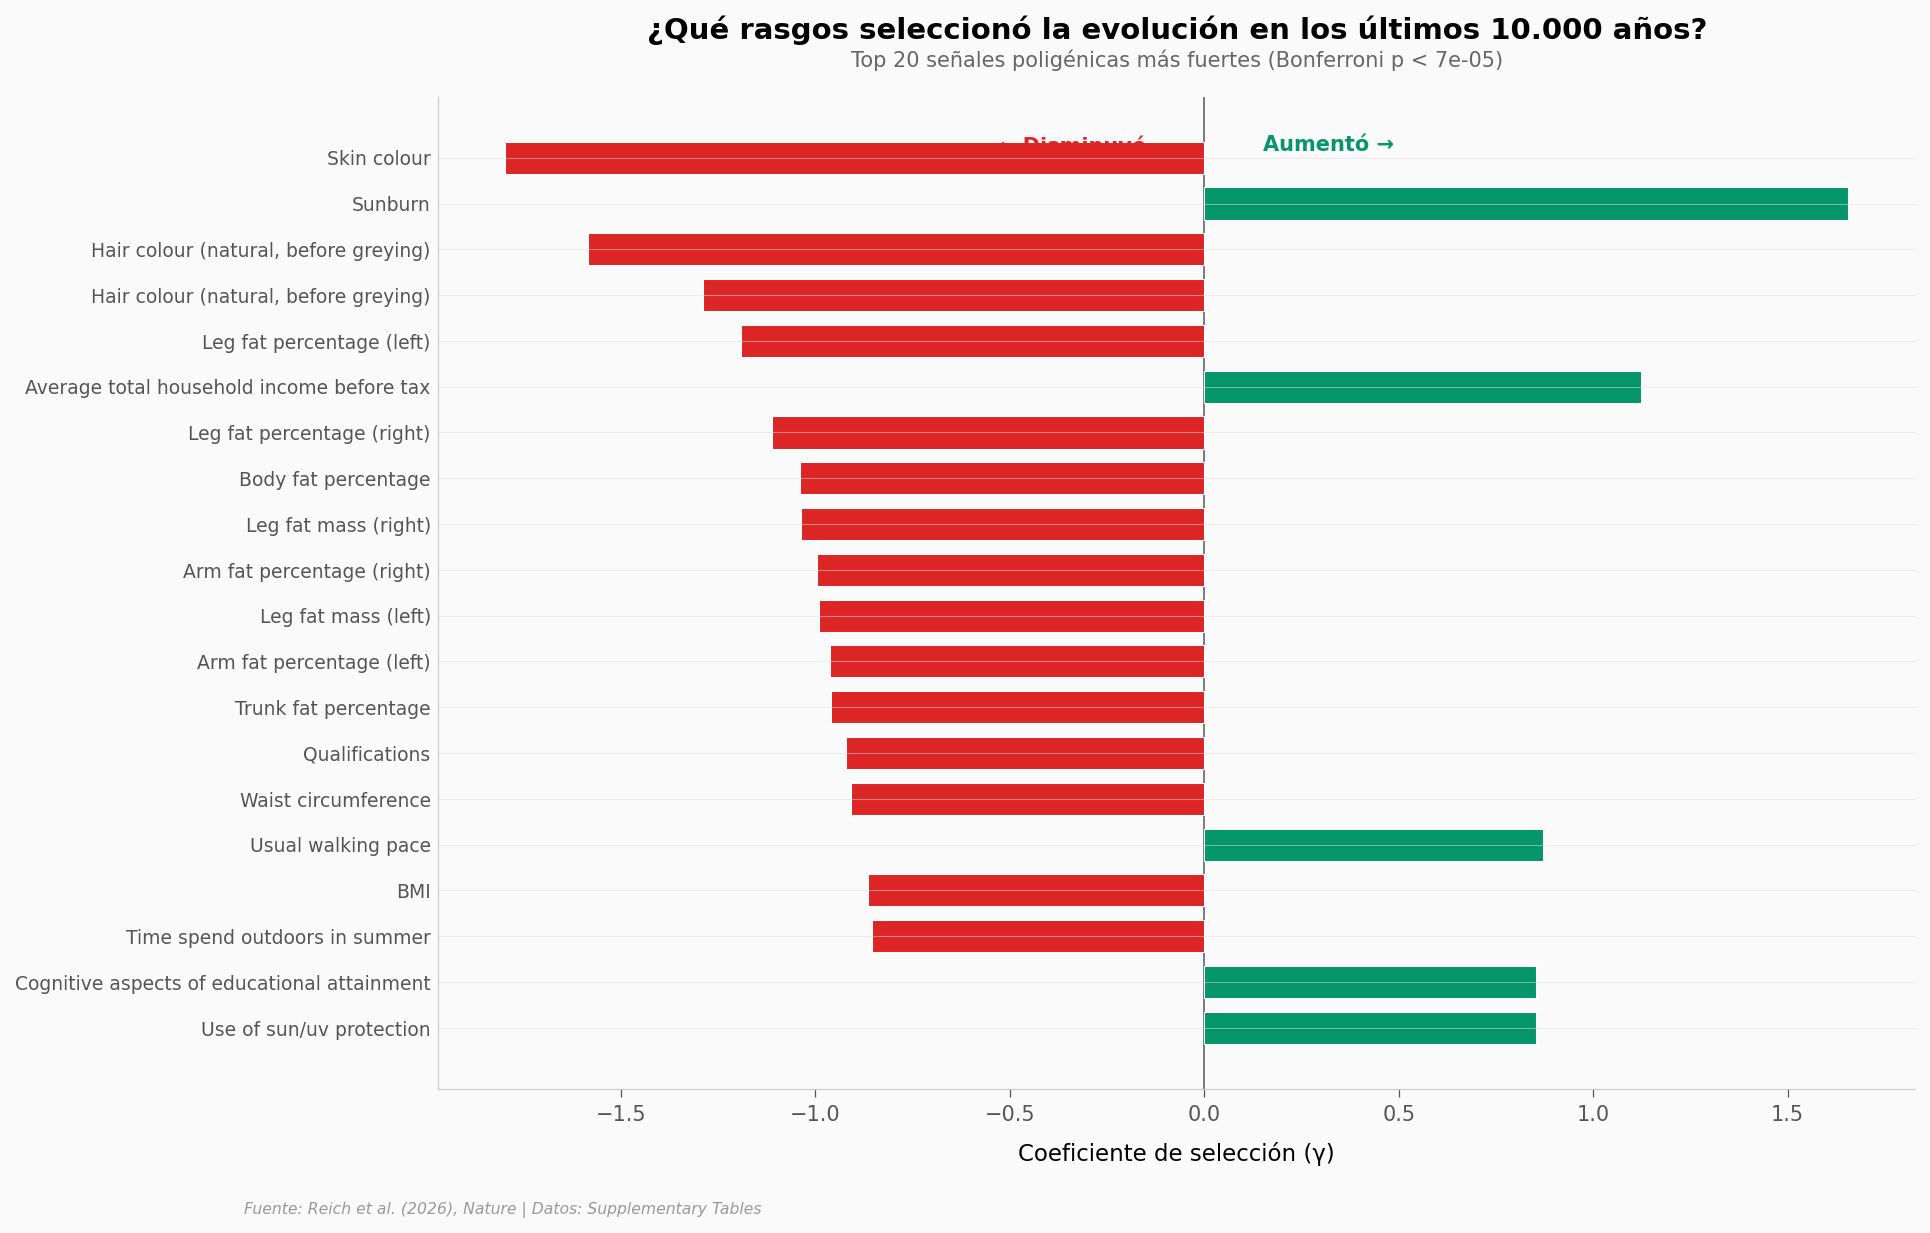

In [2]:
# ── Top N señales de selección direccional ──
sig = [p for p in phenos if p['gamma_p'] and p['gamma_p'] < UMBRAL_BONFERRONI]
sig.sort(key=lambda x: abs(x['gamma']), reverse=True)
top = sig[:N_TOP]

fig, ax = plt.subplots(figsize=(13, 8))

names = [p['phenotype_name'] for p in top][::-1]
gammas = [p['gamma'] for p in top][::-1]
colors = [COLOR_AUMENTO if g > 0 else COLOR_ALERTA for g in gammas]

y_pos = np.arange(len(names))
bars = ax.barh(y_pos, gammas, color=colors, height=0.7, edgecolor='white', linewidth=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(names, fontsize=9)
ax.axvline(x=0, color='#666666', linewidth=0.8, zorder=0)

ax.set_xlabel('Coeficiente de selección (γ)', fontsize=11)
ax.set_title('¿Qué rasgos seleccionó la evolución en los últimos 10.000 años?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Top {N_TOP} señales poligénicas más fuertes (Bonferroni p < {UMBRAL_BONFERRONI:.0e})',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Inline labels
ax.text(-0.15, len(names) - 0.5, '← Disminuyó', fontsize=10,
        color=COLOR_ALERTA, fontweight='bold', ha='right', va='top')
ax.text(0.15, len(names) - 0.5, 'Aumentó →', fontsize=10,
        color=COLOR_AUMENTO, fontweight='bold', ha='left', va='top')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/hero_senales_seleccion.png', dpi=200, bbox_inches='tight')
plt.show()

## La piel lo cambia todo

La señal más potente de todas es la **pigmentación**: el color de piel muestra un coeficiente de selección de γ = −1,80 con una significancia astronómica (p = 5,7 × 10⁻⁷⁴). El color del pelo y la sensibilidad al sol van justo detrás. En 10.000 años, la selección empujó consistentemente hacia piel y pelo más claros en Eurasia occidental.

Después viene la **grasa corporal**: 16 de las 77 señales significativas son medidas de grasa — porcentaje corporal, grasa de piernas, brazos, tronco, circunferencia de cintura. Todas van en la misma dirección: **↓ disminución**.

Y en el territorio más delicado: la inteligencia fluida (γ = +0,69, p = 1,5 × 10⁻⁸) y la esquizofrenia (γ = −0,74, p = 2,5 × 10⁻⁹) también muestran señales claras. Pero el propio paper pone un freno: estos rasgos se midieron en sociedades industrializadas actuales. **Aún no se sabe cómo se traducían a fenotipos adaptativos en el pasado.** La combinación genética que hoy predice "inteligencia fluida" en un test de Reino Unido podría haber significado algo completamente diferente hace 5.000 años.

## ¿De dónde vienen estos genomas?

El dataset incluye 22.274 individuos de Eurasia occidental, distribuidos en cinco regiones: Central, Suroeste, Sureste, Norte y Este. Veamos cuándo vivieron.

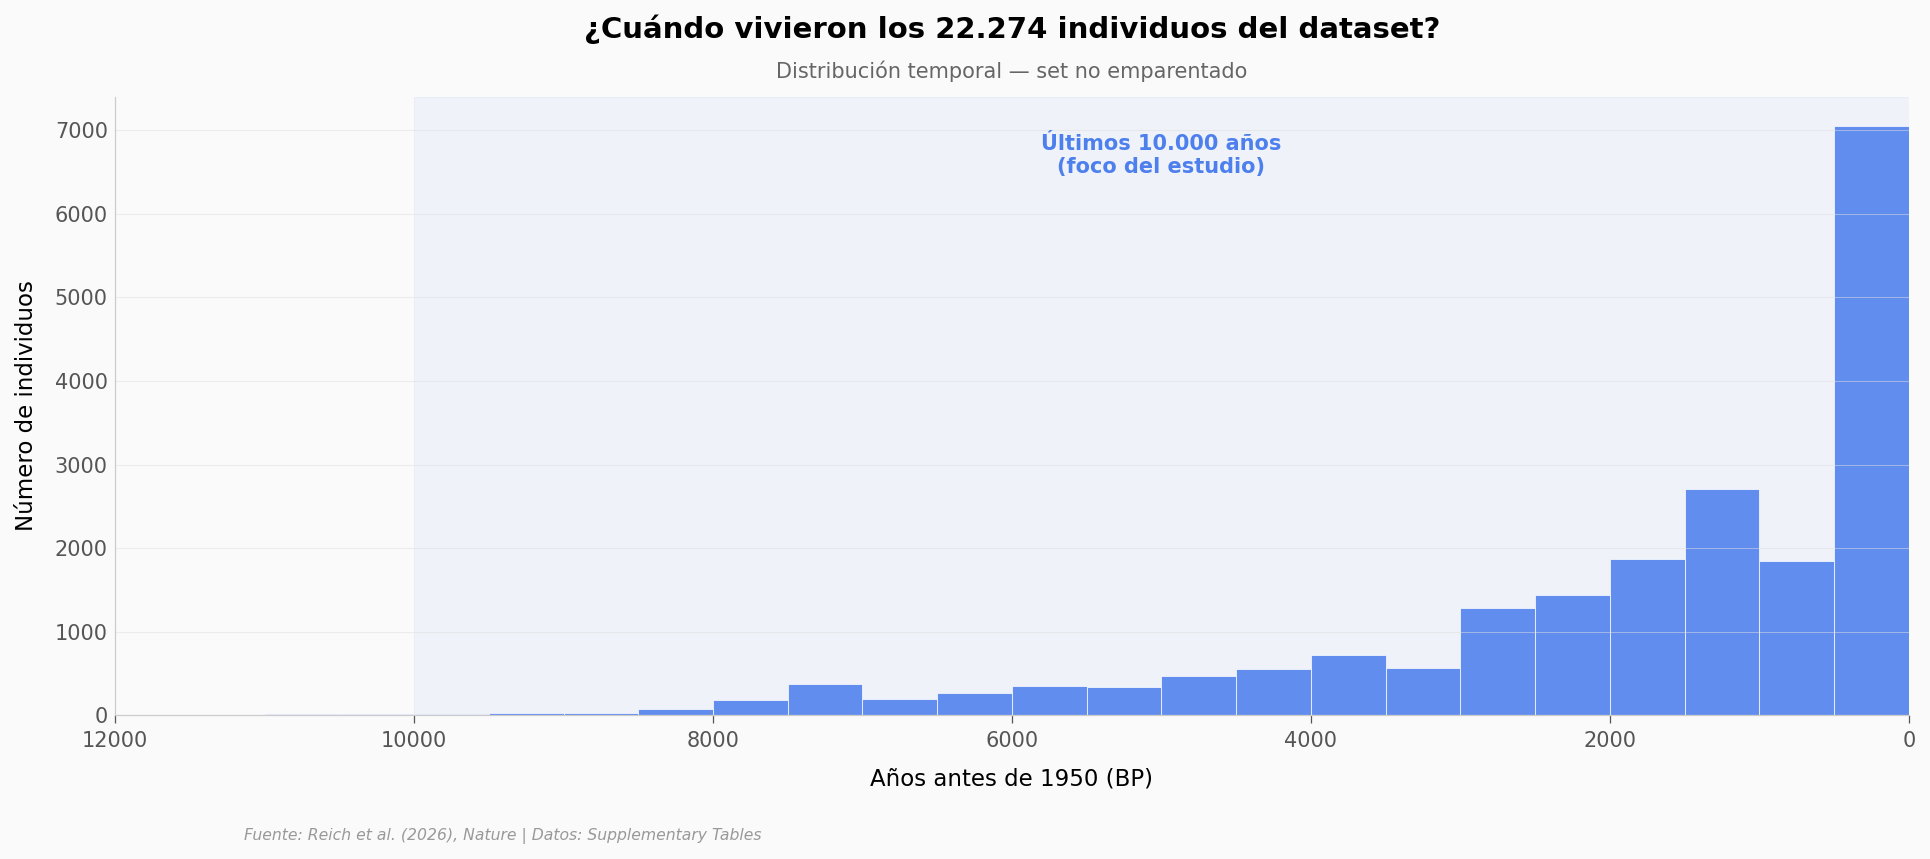

Últimos 1.000 años: 9058 individuos (44.5%)
1.000-3.000 BP: 7141 individuos (35.1%)


In [3]:
# ── Distribución temporal de los individuos ──
dates_all = [r['date_bp'] for r in unrel if r['date_bp'] is not None and r['date_bp'] <= 12000]

fig, ax = plt.subplots(figsize=(13, 5.5))

bins = np.arange(0, 12500, 500)
n, _, patches = ax.hist(dates_all, bins=bins, color=COLOR_DATOS, alpha=0.7,
                        edgecolor='white', linewidth=0.5)

# Marcar los últimos 10.000 años
ax.axvspan(0, 10000, color=COLOR_DATOS, alpha=0.05, zorder=0)
ax.text(5000, max(n) * 0.92, 'Últimos 10.000 años\n(foco del estudio)',
        fontsize=10, color=COLOR_DATOS, ha='center', fontweight='bold', alpha=0.8)

ax.set_xlabel('Años antes de 1950 (BP)', fontsize=11)
ax.set_ylabel('Número de individuos', fontsize=11)
ax.set_title('¿Cuándo vivieron los 22.274 individuos del dataset?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución temporal — set no emparentado',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Invertir eje X para que el pasado esté a la derecha
ax.invert_xaxis()
ax.set_xlim(12000, 0)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/distribucion_temporal.png', dpi=200, bbox_inches='tight')
plt.show()

# Stats
n_last_1k = sum(1 for d in dates_all if d <= 1000)
n_1k_3k = sum(1 for d in dates_all if 1000 < d <= 3000)
print(f"Últimos 1.000 años: {n_last_1k} individuos ({100*n_last_1k/len(dates_all):.1f}%)")
print(f"1.000-3.000 BP: {n_1k_3k} individuos ({100*n_1k_3k/len(dates_all):.1f}%)")

## El volcán de la selección

Cada punto es un rasgo. El eje horizontal muestra la fuerza y dirección de la selección (γ). El eje vertical muestra la significancia estadística. Los rasgos que aparecen arriba y a los lados son los que la evolución empujó con más fuerza y más consistencia.

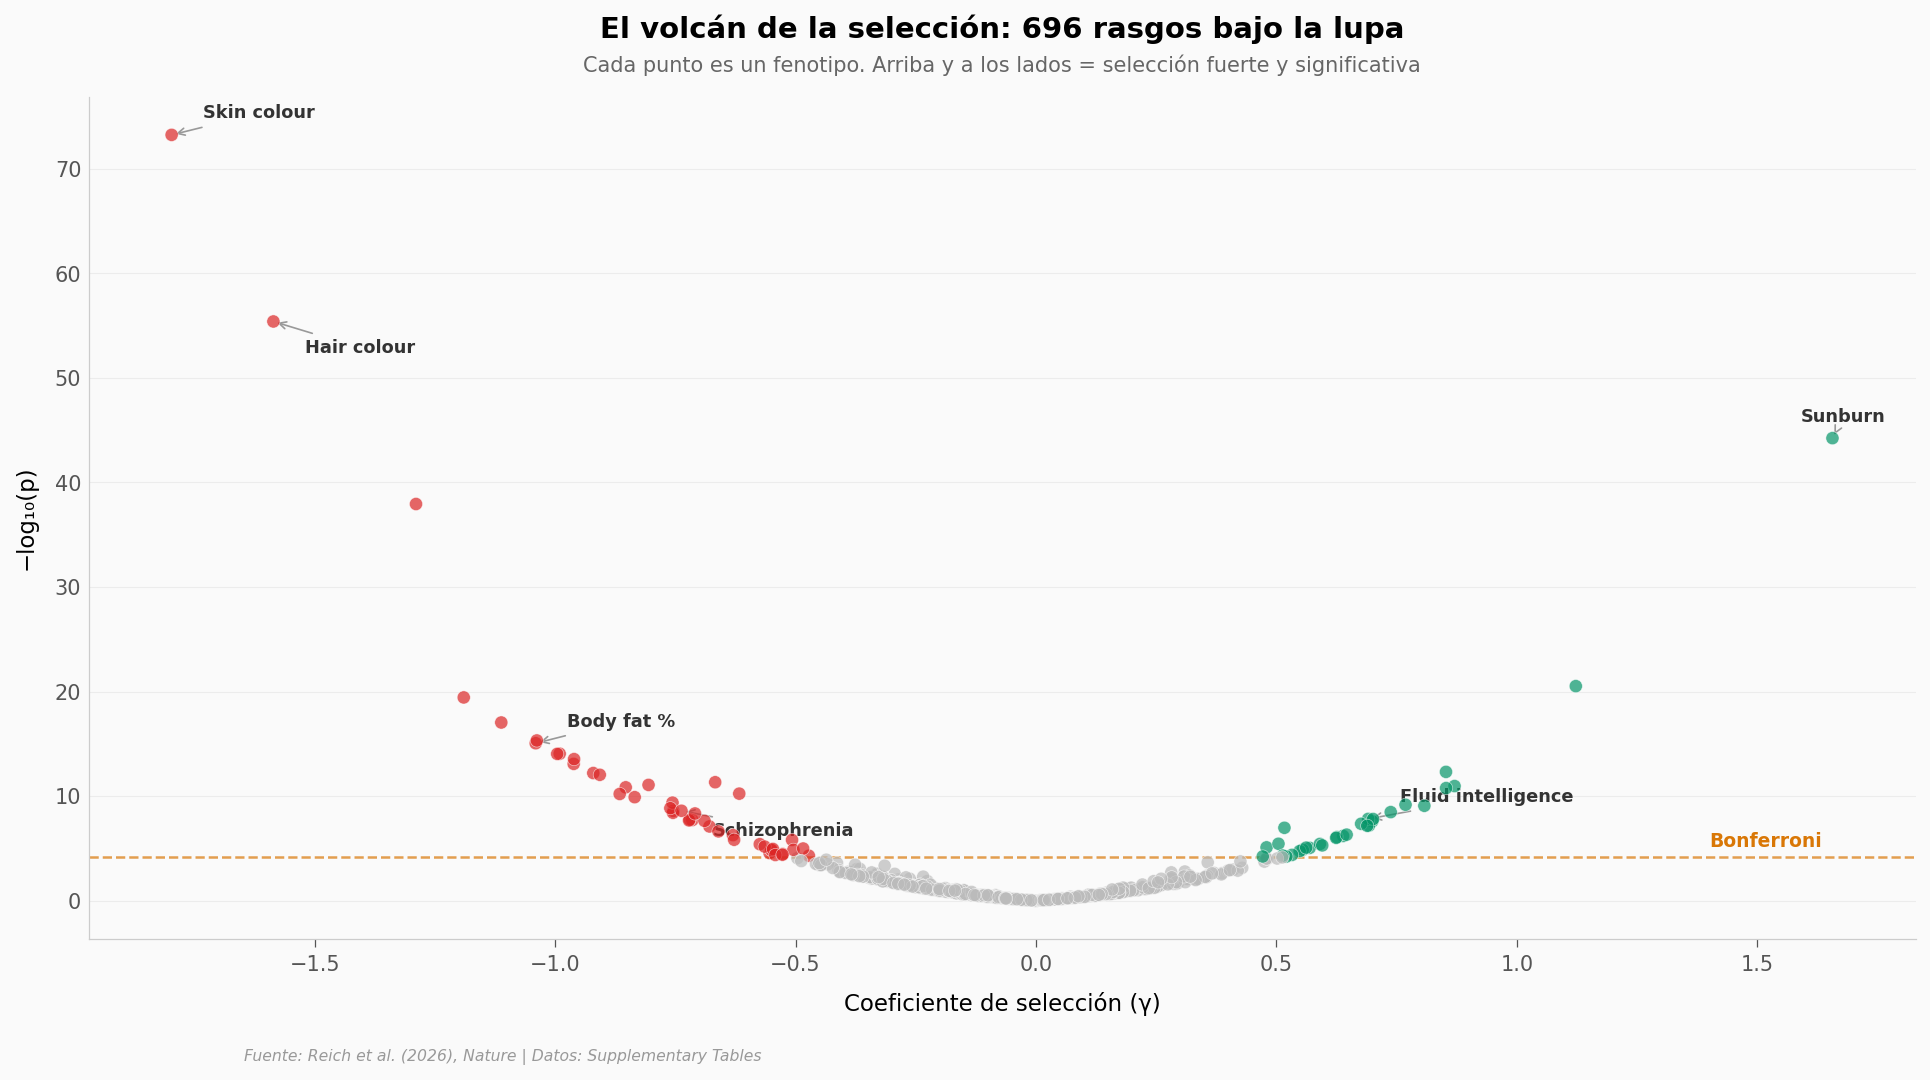

In [4]:
# ── Volcano plot: fuerza vs significancia ──
gammas_all = [p['gamma'] for p in phenos if p['gamma'] is not None and p['gamma_p'] is not None]
log_ps = [-math.log10(p['gamma_p']) for p in phenos if p['gamma'] is not None and p['gamma_p'] is not None and p['gamma_p'] > 0]
gammas_plot = [p['gamma'] for p in phenos if p['gamma'] is not None and p['gamma_p'] is not None and p['gamma_p'] > 0]

fig, ax = plt.subplots(figsize=(13, 7))

# Color por significancia
colors_v = []
for p in phenos:
    if p['gamma'] is None or p['gamma_p'] is None or p['gamma_p'] == 0:
        continue
    if p['gamma_p'] < UMBRAL_BONFERRONI:
        colors_v.append(COLOR_AUMENTO if p['gamma'] > 0 else COLOR_ALERTA)
    else:
        colors_v.append(COLOR_CONTEXTO)

ax.scatter(gammas_plot, log_ps, c=colors_v, s=40, alpha=0.7,
           edgecolors='white', linewidths=0.3, zorder=5)

# Umbral Bonferroni
ax.axhline(y=-math.log10(UMBRAL_BONFERRONI), color=COLOR_REF, linewidth=1.2,
           linestyle='--', alpha=0.7)
ax.text(1.4, -math.log10(UMBRAL_BONFERRONI) + 1, 'Bonferroni',
        fontsize=9, color=COLOR_REF, fontweight='bold')

# Anotar top hits
top_hits = [
    ('Skin colour', -1.797, 5.69e-74),
    ('Hair colour', -1.586, 4.00e-56),
    ('Sunburn', 1.656, 5.77e-45),
    ('Body fat %', -1.040, 8.75e-16),
    ('Fluid intelligence', 0.691, 1.51e-08),
    ('Schizophrenia', -0.737, 2.51e-09),
]
offsets = [(15, 8), (15, -15), (-15, 8), (15, 8), (15, 8), (15, -12)]
for (name, g, p), (dx, dy) in zip(top_hits, offsets):
    ax.annotate(name, xy=(g, -math.log10(p)), fontsize=8.5,
                fontweight='bold', color='#333333',
                xytext=(dx, dy), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='#999999', lw=0.8))

ax.set_xlabel('Coeficiente de selección (γ)', fontsize=11)
ax.set_ylabel('−log₁₀(p)', fontsize=11)
ax.set_title('El volcán de la selección: 696 rasgos bajo la lupa',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto es un fenotipo. Arriba y a los lados = selección fuerte y significativa',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/volcano_seleccion.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan extrema es la señal de pigmentación?

El color de piel tiene un γ de −1,80. Pero ¿qué tan lejos está eso del resto de las 696 señales?

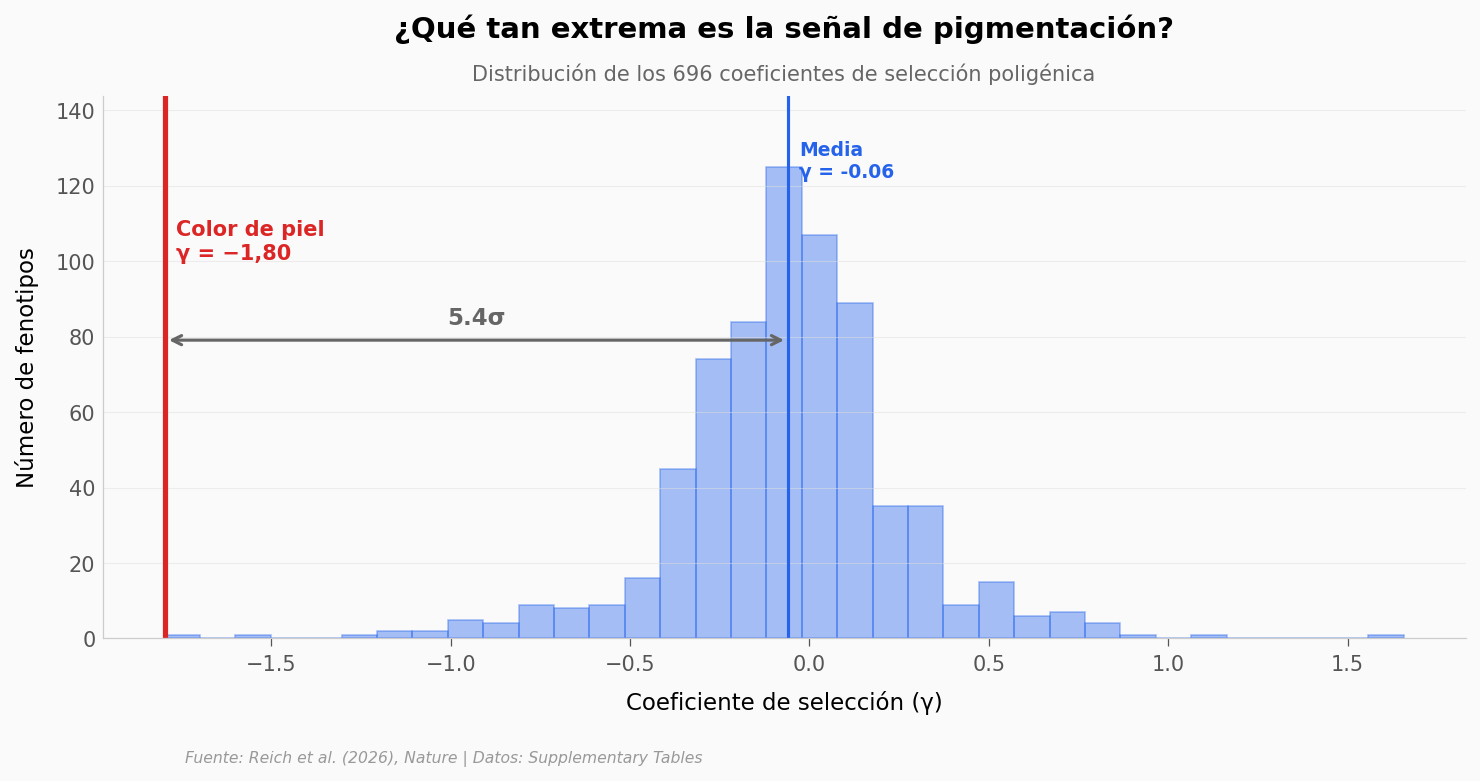

Distancia de pigmentación a la media: 5.4 desviaciones estándar
Solo 3 de 696 fenotipos tienen |γ| > 1,5


In [5]:
# ── Histograma de anomalía: distribución de coeficientes γ ──
all_gammas = [p['gamma'] for p in phenos if p['gamma'] is not None]
mean_gamma = statistics.mean(all_gammas)
skin_gamma = -1.797  # Señal más fuerte: color de piel

fig, ax = plt.subplots(figsize=(10, 5))

n_hist, bins_h, patches_h = ax.hist(all_gammas, bins=35, color=COLOR_DATOS, alpha=0.4,
                                     edgecolor=COLOR_DATOS, linewidth=0.8)

y_max = max(n_hist) * 1.15
ax.set_ylim(0, y_max)

# Media
ax.axvline(x=mean_gamma, color=COLOR_DATOS, linewidth=1.5, label=f'Media (γ = {mean_gamma:.2f})')
ax.text(mean_gamma + 0.03, y_max * 0.85, f'Media\nγ = {mean_gamma:.2f}',
        fontsize=9, color=COLOR_DATOS, fontweight='bold')

# Señal de pigmentación
ax.axvline(x=skin_gamma, color=COLOR_ALERTA, linewidth=2.5)
ax.text(skin_gamma + 0.03, y_max * 0.7, 'Color de piel\nγ = −1,80',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold')

# Flecha bidireccional
ax.annotate('', xy=(skin_gamma, y_max * 0.55), xytext=(mean_gamma, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
diff_sd = abs(skin_gamma - mean_gamma) / statistics.stdev(all_gammas)
ax.text((skin_gamma + mean_gamma) / 2, y_max * 0.58, f'{diff_sd:.1f}σ',
        fontsize=11, color='#666666', ha='center', fontweight='bold')

ax.set_xlabel('Coeficiente de selección (γ)', fontsize=11)
ax.set_ylabel('Número de fenotipos', fontsize=11)
ax.set_title('¿Qué tan extrema es la señal de pigmentación?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución de los 696 coeficientes de selección poligénica',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/histograma_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Distancia de pigmentación a la media: {diff_sd:.1f} desviaciones estándar")
print(f"Solo {sum(1 for g in all_gammas if abs(g) > 1.5)} de 696 fenotipos tienen |γ| > 1,5")

### ¿Soportado por los datos?

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| "Cientos de alelos bajo selección direccional" | ✅ | 77 señales poligénicas Bonferroni-significativas entre 696 testadas. Las "cientos de alelos" individuales están en la Tabla Suplementaria 4 (9,7 millones de variantes, no disponible en el XLSX) |
| "Disminución en grasa corporal predicha" | ✅ | 16 medidas de grasa Bonferroni-significativas, todas con γ negativo. La más fuerte: grasa de pierna izquierda (γ = −1,19, p = 3,6 × 10⁻²⁰) |
| "Disminución en esquizofrenia predicha" | ✅ | γ = −0,74, p = 2,5 × 10⁻⁹ (Bonferroni-significativo) |
| "Aumento en rendimiento cognitivo" | ⚠️ | Inteligencia fluida: γ = +0,69, p = 1,5 × 10⁻⁸ (significativo). Pero "rendimiento cognitivo" genérico tiene resultados mixtos (p = 0,018 a 0,67 según la fuente). El paper reconoce que estos rasgos se midieron en sociedades industrializadas actuales |
| Pigmentación: señal más fuerte de todas | ✅ | Color de piel: γ = −1,80, p = 5,7 × 10⁻⁷⁴ — la más significativa de las 696 por un amplio margen (5,4σ de la media) |

> **Limitaciones:**
> - Los rasgos predichos (grasa, cognición, esquizofrenia) se basan en asociaciones genéticas medidas en sociedades industrializadas modernas — su significado fenotípico en el pasado es desconocido
> - El XLSX no incluye la Tabla 4 (9,7 millones de variantes individuales) — nuestro análisis se limita a las 696 señales poligénicas
> - 8.122 de los 20.374 individuos no emparentados tienen país anonimizado
> - El set no emparentado del XLSX (20.374) difiere del número reportado en el paper (15.836) por filtros adicionales de calidad

## Ahora tú

1. **¿Hay diferencias entre regiones?** Filtra `individuos_antiguos.csv` por región (C, SW, SE, N, E) y compara la distribución temporal. ¿La muestra es igual de densa en todas las regiones, o hay huecos? Pista: `Counter(r['region'] for r in unrel if r['date_bp'] and r['date_bp'] < 3000)`

2. **¿Qué pasa con la talla?** De las 11 medidas de altura en el dataset, ninguna alcanza significancia Bonferroni. Busca los fenotipos con "height" o "standing" — ¿van en la misma dirección? ¿Se acercan al umbral? Pista: `[p for p in phenos if 'eight' in p['phenotype_name'].lower()]`

3. **¿Son independientes las señales de grasa?** Hay 16 medidas de grasa significativas, pero muchas son la misma medición en diferente parte del cuerpo (pierna izquierda, pierna derecha, brazo...). ¿Cuántas son verdaderamente independientes? Pista: compara los γ — si son casi idénticos, miden lo mismo.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Qué categoría tiene más señales significativas?

categorias = {
    'Pigmentación': ['skin', 'hair', 'sunburn', 'sun/', 'tanning'],
    'Grasa corporal': ['fat', 'bmi', 'body mass', 'waist', 'adipos'],
    'Cognitivo': ['intelligence', 'cognitive', 'educational', 'qualific'],
    'Neuropsiquiátrico': ['schizophrenia', 'bipolar', 'depres'],
    'Metabólico': ['glucose', 'glycated', 'cholesterol', 'albumin'],
    'Inmune': ['white blood', 'lymphocyte', 'neutrophil', 'eosinoph'],
}

print(f"{'Categoría':<20} {'Total':>6} {'Bonf.':>6} {'% sig':>8} {'γ medio':>8}")
print('─' * 52)
for cat, keywords in categorias.items():
    matches = [p for p in phenos
               if any(kw in p['phenotype_name'].lower() for kw in keywords)]
    n_sig = sum(1 for p in matches
                if p['gamma_p'] and p['gamma_p'] < UMBRAL_BONFERRONI)
    gammas_cat = [p['gamma'] for p in matches if p['gamma'] is not None]
    mean_g = statistics.mean(gammas_cat) if gammas_cat else 0
    pct = 100 * n_sig / len(matches) if matches else 0
    print(f"{cat:<20} {len(matches):>6} {n_sig:>6} {pct:>7.1f}% {mean_g:>+8.3f}")

Categoría             Total  Bonf.    % sig  γ medio
────────────────────────────────────────────────────
Pigmentación              6      6   100.0%   -0.244
Grasa corporal           33     16    48.5%   -0.529
Cognitivo                16      7    43.8%   +0.282
Neuropsiquiátrico         7      2    28.6%   -0.259
Metabólico               17      1     5.9%   -0.013
Inmune                   12      0     0.0%   -0.033


---

### Créditos

- **Paper:** Ancient DNA reveals pervasive directional selection across West Eurasia
- **DOI:** [10.1038/s41586-026-10358-1](https://doi.org/10.1038/s41586-026-10358-1)
- **Datos:** Supplementary Tables (Nature, 2026) — 22.274 individuos + 696 tests poligénicos
- **Licencia datos:** Supplementary Materials, Nature
- **Notebook:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab)